<h1 style = "color:red; text-align:center; background-color:BLACK"> CHURN DATASET TRAINING </H1>

In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
import plotly.express as px 
from sklearn.preprocessing import StandardScaler , OrdinalEncoder , LabelEncoder 
from sklearn.model_selection import train_test_split , LeaveOneOut , LeavePOut ,StratifiedKFold
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier , GradientBoostingClassifier 
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('Churn_Modelling.csv')

In [4]:
df.isnull().mean()*100

RowNumber          0.0
CustomerId         0.0
Surname            0.0
CreditScore        0.0
Geography          0.0
Gender             0.0
Age                0.0
Tenure             0.0
Balance            0.0
NumOfProducts      0.0
HasCrCard          0.0
IsActiveMember     0.0
EstimatedSalary    0.0
Exited             0.0
dtype: float64

In [7]:
desc = df.describe()
desc


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [8]:
# check null values
print(len(df) - desc.loc['count'])

RowNumber          0.0
CustomerId         0.0
CreditScore        0.0
Age                0.0
Tenure             0.0
Balance            0.0
NumOfProducts      0.0
HasCrCard          0.0
IsActiveMember     0.0
EstimatedSalary    0.0
Exited             0.0
Name: count, dtype: float64


In [9]:
#outlier check 
print(desc.loc["max"] - desc.loc["75%"])

RowNumber            2499.7500
CustomerId          62456.2500
CreditScore           132.0000
Age                    48.0000
Tenure                  3.0000
Balance            123253.8500
NumOfProducts           2.0000
HasCrCard               0.0000
IsActiveMember          0.0000
EstimatedSalary     50604.2325
Exited                  1.0000
dtype: float64


In [10]:
# skewness
print(desc.loc["mean"] - desc.loc["50%"])

RowNumber              0.000000
CustomerId           202.569400
CreditScore           -1.471200
Age                    1.921800
Tenure                 0.012800
Balance           -20712.650712
NumOfProducts          0.530200
HasCrCard             -0.294500
IsActiveMember        -0.484900
EstimatedSalary     -103.675119
Exited                 0.203700
dtype: float64


In [11]:
import sheryanalysis.analyzer as sh 
sh.analyze(df)


🔍 Basic Analysis Report
------------------------------------------------------------
📏 Shape: (10000, 14)
🧱 Columns: ['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

✅ No null values found

🔠 Categorical Columns: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'Exited']

🔢 Numerical Columns: ['RowNumber', 'CustomerId', 'Balance', 'EstimatedSalary']

📝 Text Columns: ['Surname']


{'shape': (10000, 14),
 'columns': ['RowNumber',
  'CustomerId',
  'Surname',
  'CreditScore',
  'Geography',
  'Gender',
  'Age',
  'Tenure',
  'Balance',
  'NumOfProducts',
  'HasCrCard',
  'IsActiveMember',
  'EstimatedSalary',
  'Exited'],
 'dtypes': {'RowNumber': dtype('int64'),
  'CustomerId': dtype('int64'),
  'Surname': dtype('O'),
  'CreditScore': dtype('int64'),
  'Geography': dtype('O'),
  'Gender': dtype('O'),
  'Age': dtype('int64'),
  'Tenure': dtype('int64'),
  'Balance': dtype('float64'),
  'NumOfProducts': dtype('int64'),
  'HasCrCard': dtype('int64'),
  'IsActiveMember': dtype('int64'),
  'EstimatedSalary': dtype('float64'),
  'Exited': dtype('int64')},
 'null_counts': {'RowNumber': 0,
  'CustomerId': 0,
  'Surname': 0,
  'CreditScore': 0,
  'Geography': 0,
  'Gender': 0,
  'Age': 0,
  'Tenure': 0,
  'Balance': 0,
  'NumOfProducts': 0,
  'HasCrCard': 0,
  'IsActiveMember': 0,
  'EstimatedSalary': 0,
  'Exited': 0},
 'total_rows': 10000,
 'column_types': {'categorical'

In [ ]:
from ydata_profiling import ProfileReport
df = pd.read_csv("Churn_Modelling.csv")
data = ProfileReport(df , title  = "Churn dataset visulization " , explorative=True)
data.to_file("data.html")

# Basic EDA

In [3]:
num = df.select_dtypes(include='number').columns
cat = df.select_dtypes(include='object').columns

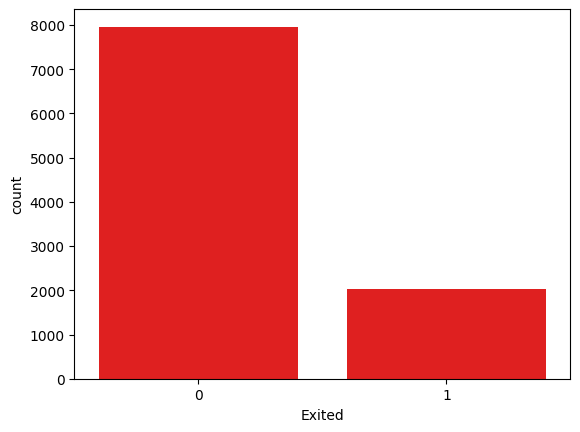

In [5]:


sns.countplot(x='Exited', data=df , color = "red")
plt.show()

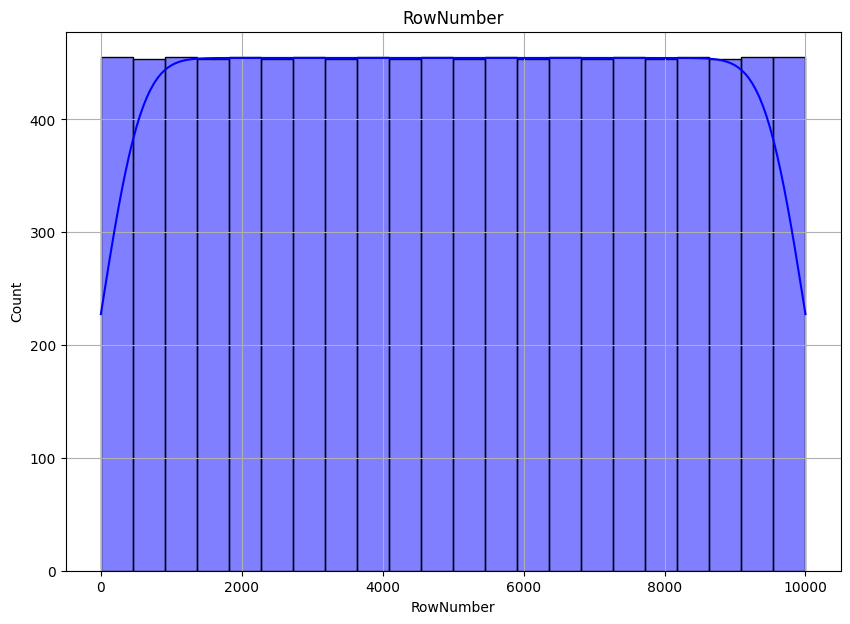

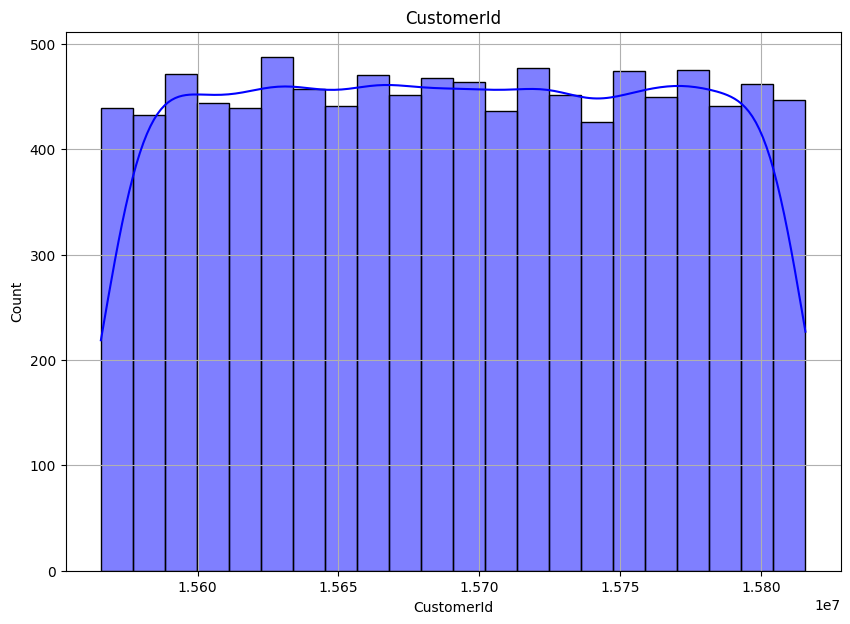

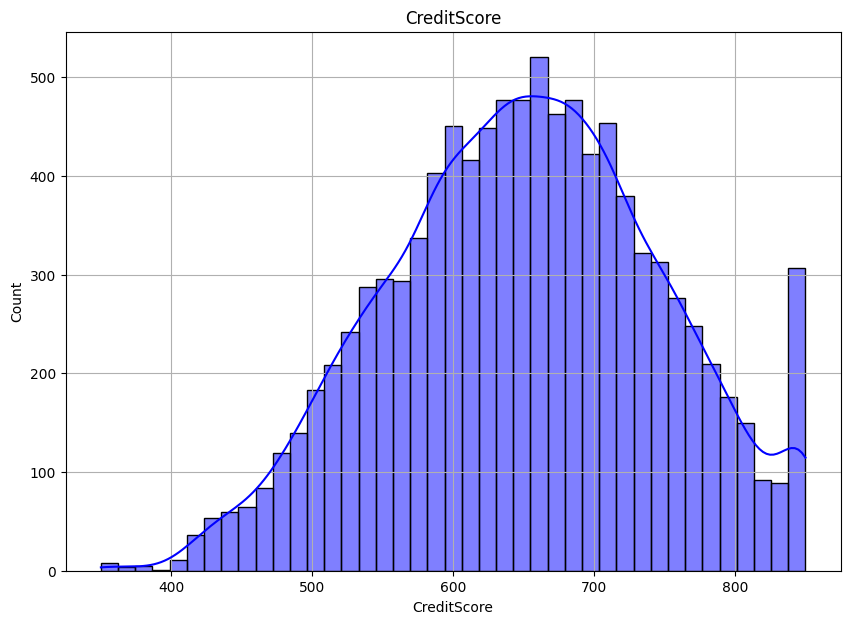

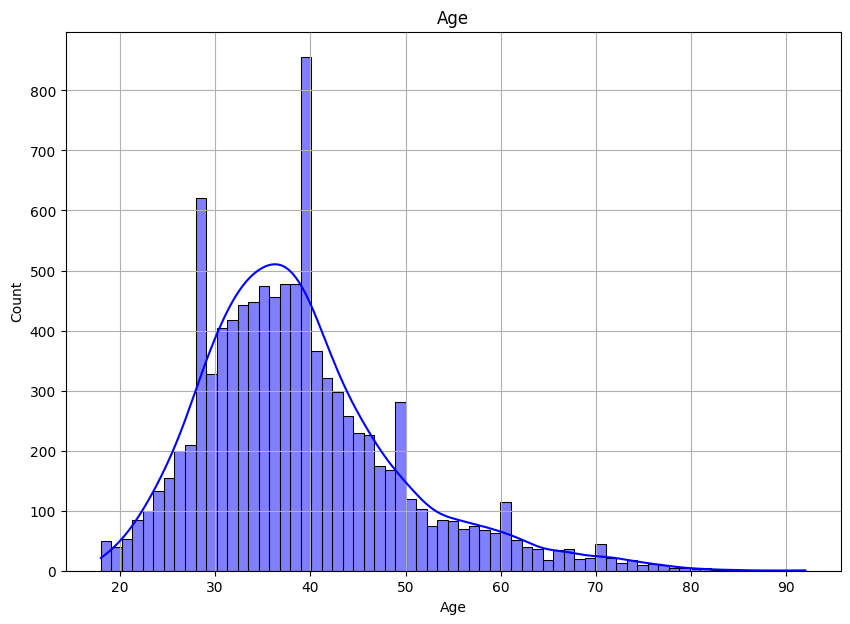

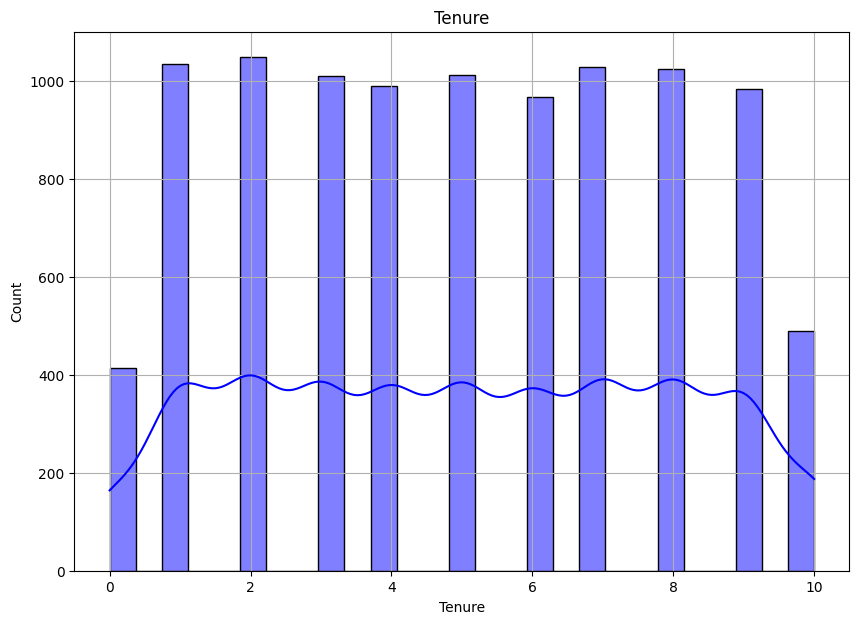

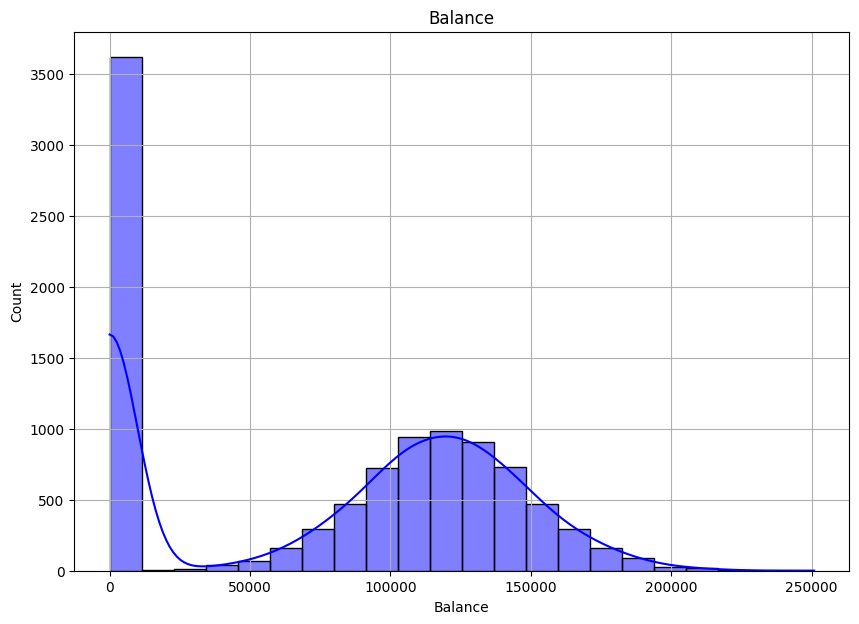

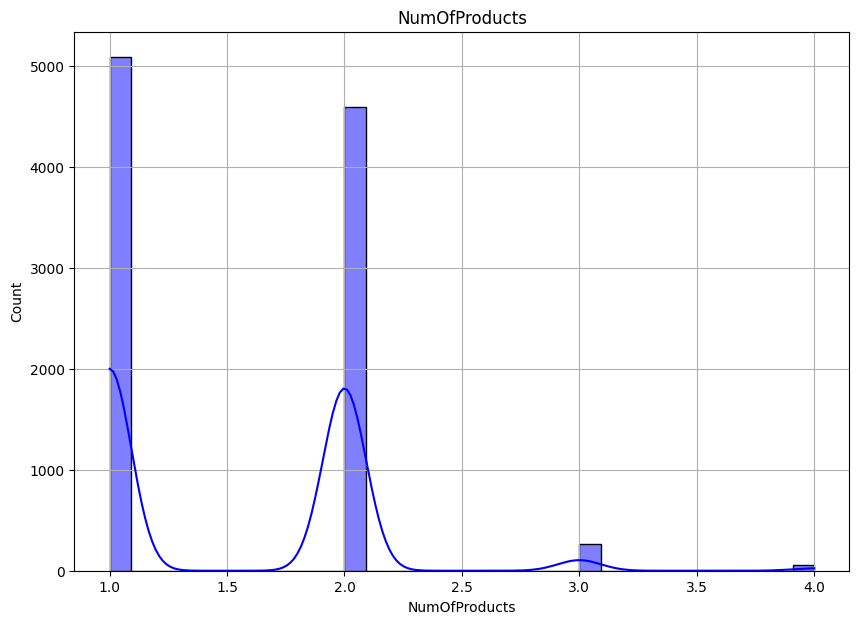

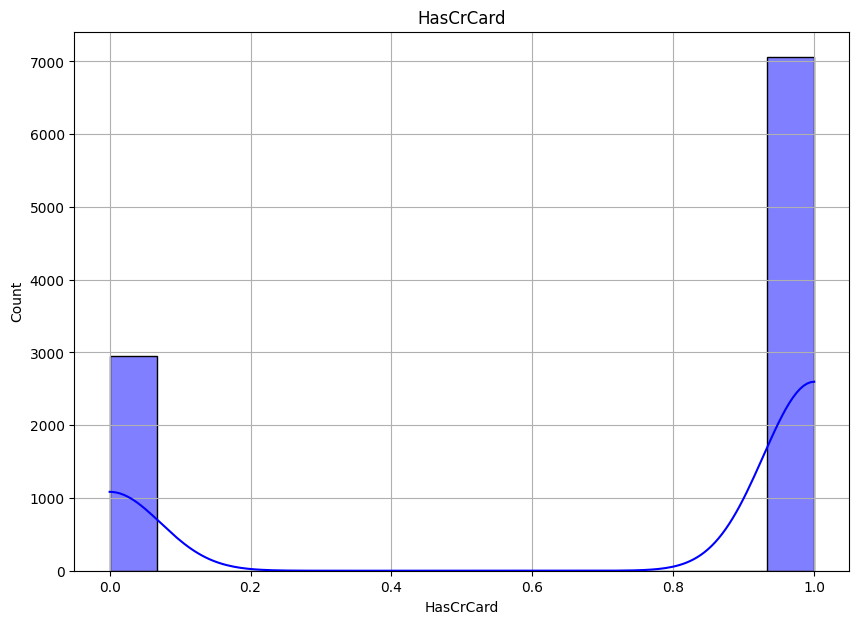

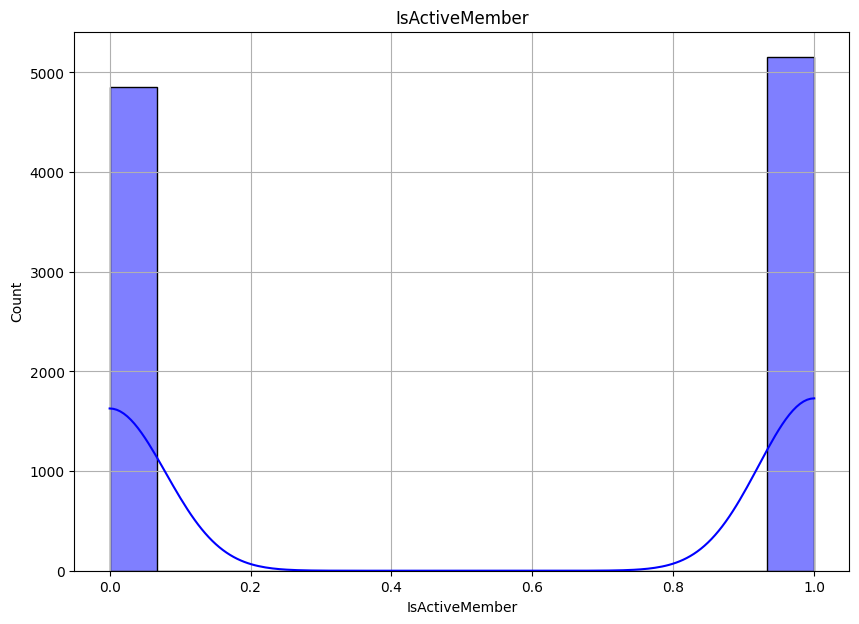

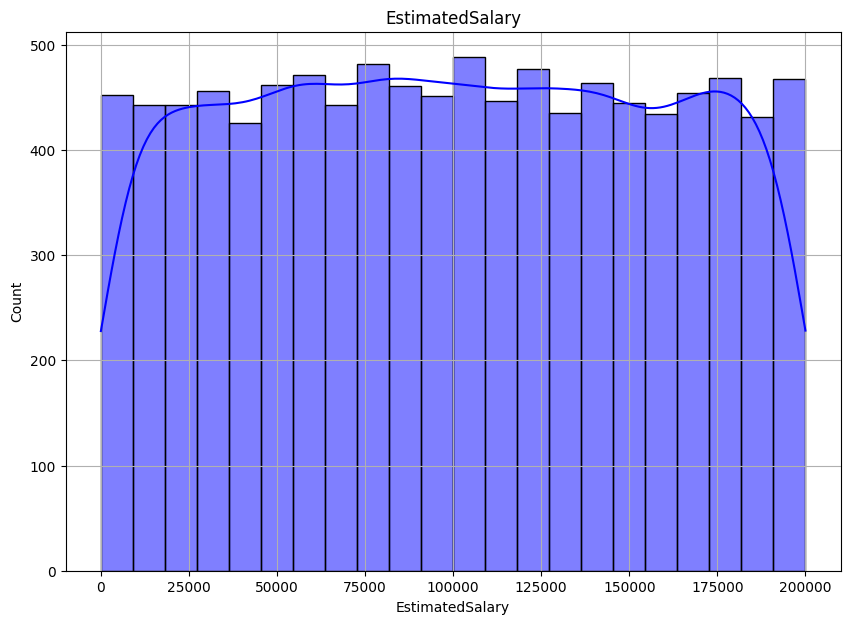

In [11]:
for i in num:
    if i != "Exited":
        plt.figure(figsize=(10,7))
        sns.histplot(x=df[i], kde=True , color = "blue")
        plt.title(i)
        plt.xlabel(i)
        plt.ylabel("Count")
        plt.grid()
        plt.show()

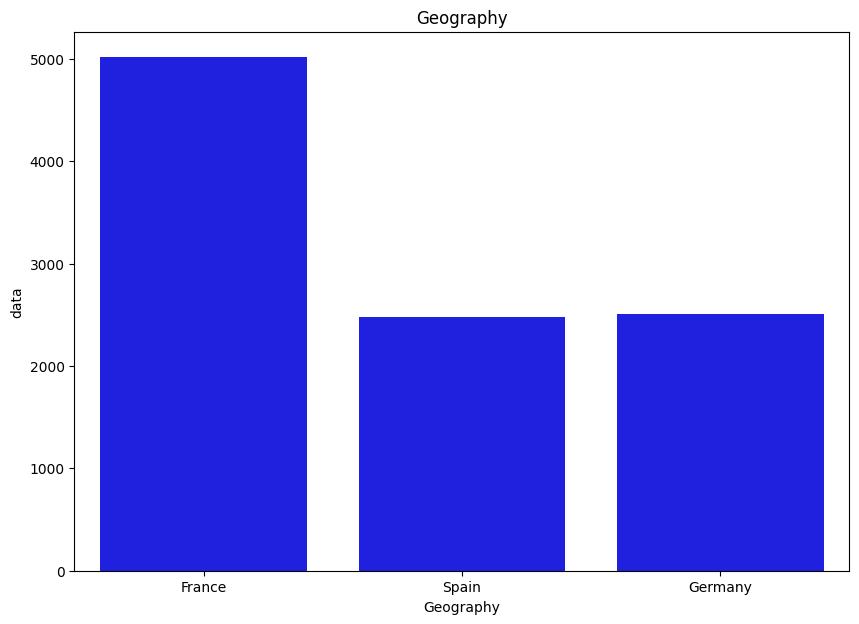

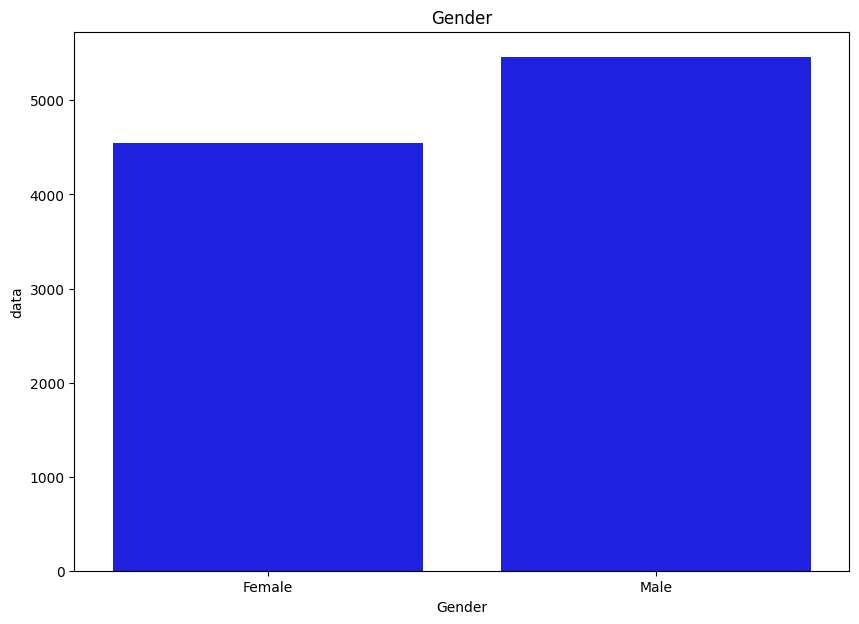

In [15]:
for i in cat:
    if i != "Surname":
        plt.figure(figsize=(10,7))
        sns.countplot(x=df[i] , color = "blue")
        plt.title(i)
        plt.xlabel(i)
        plt.ylabel("data")
        plt.show()

# Data Cleaning

In [5]:
df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1, inplace=True)

In [4]:
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [4]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

In [6]:
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,0,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,0,41,1,83807.86,1,0,1,112542.58,0
2,502,France,0,42,8,159660.80,3,1,0,113931.57,1
3,699,France,0,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,0,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,1,39,5,0.00,2,1,0,96270.64,0
9996,516,France,1,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,0,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,1,42,3,75075.31,2,1,0,92888.52,1


In [6]:
import category_encoders as ce

encoder = ce.TargetEncoder(cols=['Geography'])
df['Geography'] = encoder.fit_transform(df['Geography'], df['Exited'])

In [8]:
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,0.161548,0,42,2,0.00,1,1,1,101348.88,1
1,608,0.166734,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0.161548,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0.161548,0,39,1,0.00,2,0,0,93826.63,0
4,850,0.166734,0,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,0.161548,1,39,5,0.00,2,1,0,96270.64,0
9996,516,0.161548,1,35,10,57369.61,1,1,1,101699.77,0
9997,709,0.161548,0,36,7,0.00,1,0,1,42085.58,1
9998,772,0.324432,1,42,3,75075.31,2,1,0,92888.52,1


In [7]:
x = df.drop('Exited', axis=1)
y = df['Exited']


In [11]:
x

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,0.161548,0,42,2,0.00,1,1,1,101348.88
1,608,0.166734,0,41,1,83807.86,1,0,1,112542.58
2,502,0.161548,0,42,8,159660.80,3,1,0,113931.57
3,699,0.161548,0,39,1,0.00,2,0,0,93826.63
4,850,0.166734,0,43,2,125510.82,1,1,1,79084.10
...,...,...,...,...,...,...,...,...,...,...
9995,771,0.161548,1,39,5,0.00,2,1,0,96270.64
9996,516,0.161548,1,35,10,57369.61,1,1,1,101699.77
9997,709,0.161548,0,36,7,0.00,1,0,1,42085.58
9998,772,0.324432,1,42,3,75075.31,2,1,0,92888.52


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
x_test_scaled = scaler.transform(X_test)

In [16]:
from imblearn.over_sampling import SMOTE

In [17]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBRFClassifier
from sklearn.neighbors import KNeighborsClassifier

models = {

    "Random Forest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {
            "n_estimators": [200, 300, 500],
            "max_depth": [None, 5, 10],
            "min_samples_split": [2, 5],
            "min_samples_leaf": [1, 2],
        },
    },

    "Gradient Boosting": {
        "model": GradientBoostingClassifier(),
        "params": {
            "n_estimators": [100, 200],
            "learning_rate": [0.01, 0.05, 0.1],
            "max_depth": [3, 5],
        },
    },

    "XGBoost": {
        "model": XGBRFClassifier(objective="binary:logistic"),
        "params": {
            "n_estimators": [300, 500],
            "learning_rate": [0.01, 0.05, 0.1],
            "max_depth": [3, 5, 7],
            "subsample": [0.7, 0.8, 1.0],
            "colsample_bytree": [0.7, 0.8, 1.0],
        },
    },

    "SVC": {
        "model": SVC(),
        "params": {
            "C": [0.1, 1, 10],
            "kernel": ["rbf", "linear"]
        },
    },

    "Decision Tree": {
        "model": DecisionTreeClassifier(),
        "params": {
            "criterion": ["gini", "entropy"],
            "max_depth": [None, 5, 10, 20],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf": [1, 2, 4]
        },
    },

    "Logistic Classifier": {
        "model": LogisticRegression(max_iter=1000),
        "params": {
            "C": [0.01, 0.1, 1, 10],
            "penalty": ["l2"],
            "solver": ["lbfgs"]
        },
    },
    "knn":{
        "model":KNeighborsClassifier(),
        "params":{
            "n_neighbors":[4 , 5 , 6 , 7 , 8],
            "weight" : ['uniform', 'distance'],
            "algorithm": ['auto', 'ball_tree', 'kd_tree', 'brute']
            
        }
    }
}

In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix , roc_auc_score
import numpy as np

for name, mp in models.items():
    
    model = mp["model"]
    
    model.fit(X_train_smote, y_train_smote)
    
    y_pred = model.predict(x_test_scaled)
    
    print("Model:", name)
    
    print(f"Train Score: {model.score(X_train_smote, y_train_smote)}")
    print(f"Test Score : {model.score(x_test_scaled, y_test)}")
    
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, average='weighted'))
    print("Recall   :", recall_score(y_test, y_pred, average='weighted'))
    print("F1 Score :", f1_score(y_test, y_pred, average='weighted'))
    print("roc_auc_score : ", roc_auc_score(y_test , y_pred))
    
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    print("-" * 50)


Model: Random Forest
Train Score: 1.0
Test Score : 0.8505
Accuracy : 0.8505
Precision: 0.8470872762148338
Recall   : 0.8505
F1 Score : 0.8486213023032774
roc_auc_score :  0.7512671185699967
Confusion Matrix:
[[1470  137]
 [ 162  231]]
--------------------------------------------------
Model: Gradient Boosting
Train Score: 0.8827092511013216
Test Score : 0.846
Accuracy : 0.846
Precision: 0.855075004415572
Recall   : 0.846
F1 Score : 0.8497557189898894
roc_auc_score :  0.7830674007324825
Confusion Matrix:
[[1425  182]
 [ 126  267]]
--------------------------------------------------
Model: XGBoost
Train Score: 0.8331497797356828
Test Score : 0.8115
Accuracy : 0.8115
Precision: 0.8431940263618266
Recall   : 0.8115
F1 Score : 0.822249045776665
roc_auc_score :  0.7760157136953311
Confusion Matrix:
[[1341  266]
 [ 111  282]]
--------------------------------------------------
Model: SVC
Train Score: 0.8285871617369415
Test Score : 0.783
Accuracy : 0.783
Precision: 0.8311573269350394
Recall   :

# Save Your Model

In [ ]:
import pickle

pickle.dump(model, open("churn_model.pkl", "wb"))

pickle.dump(scaler, open("scaler.pkl", "wb"))